In [1]:
# pipenv install pandas seaborn plotly scikit-learn matplotlib ipywidgets ipykernel nbformat

# EDA
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib import pyplot as plt

# ML / tSNE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.manifold import TSNE

# EDA

# Loading the data

In [2]:
df_cosmetics = pd.read_csv('./datasets/cosmetics.csv')
df_cosmetics.info()

<class 'pandas.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              1472 non-null   str    
 1   Brand             1472 non-null   str    
 2   Name              1472 non-null   str    
 3   Price             1472 non-null   int64  
 4   Rating            1472 non-null   float64
 5   Ingredients       1472 non-null   str    
 6   Combination_Skin  1472 non-null   int64  
 7   Dry_Skin          1472 non-null   int64  
 8   Normal_Skin       1472 non-null   int64  
 9   Oily_Skin         1472 non-null   int64  
 10  Sensitive_Skin    1472 non-null   int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 126.6 KB


In [3]:
df_cosmetics.head(10)

,Type,Brand,Name,Price,Rating,Ingredients,Combination_Skin,Dry_Skin,Normal_Skin,Oily_Skin,Sensitive_Skin
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1
5,Moisturizer,TATCHA,The Water Cream,68,4.2,"Water, Saccharomyces/Camellia Sinensis Leaf/Cl...",1,0,1,1,1
6,Moisturizer,DRUNK ELEPHANT,Lala Retro™ Whipped Cream,60,4.2,"Water, Glycerin, Caprylic/ Capric Triglyceride...",1,1,1,1,0
7,Moisturizer,DRUNK ELEPHANT,Virgin Marula Luxury Facial Oil,72,4.4,100% Unrefined Sclerocraya Birrea (Marula) Ker...,1,1,1,1,0
8,Moisturizer,KIEHL'S SINCE 1851,Ultra Facial Cream,29,4.4,"Water, Glycerin, Cyclohexasiloxane, Squalane, ...",1,1,1,1,1
9,Moisturizer,LA MER,Little Miss Miracle Limited-Edition Crème de l...,325,5.0,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",0,0,0,0,0


## Univariate analysis

In [4]:
# Transforming the ingredients values in a new df
df_cosmetics_eda = df_cosmetics.copy()
df_cosmetics_eda = df_cosmetics_eda['Ingredients'].str.split(',')

df_cosmetics_eda

0       [Algae (Seaweed) Extract,  Mineral Oil,  Petro...
1       [Galactomyces Ferment Filtrate (Pitera),  Buty...
2       [Water,  Dicaprylyl Carbonate,  Glycerin,  Cet...
3       [Algae (Seaweed) Extract,  Cyclopentasiloxane,...
4       [Water,  Snail Secretion Filtrate,  Phenyl Tri...
                              ...                        
1467    [Water,  Alcohol Denat.,  Potassium Cetyl Phos...
1468    [Water,  Isododecane,  Dimethicone,  Butylocty...
1469    [Water,  Dihydroxyacetone,  Glycerin,  Scleroc...
1470    [Water,  Dihydroxyacetone,  Propylene Glycol, ...
1471                      [Visit the DERMAFLASH boutique]
Name: Ingredients, Length: 1472, dtype: object

In [5]:
df_ingredients = df_cosmetics_eda.explode("Ingredients")
df_ingredients

0              Algae (Seaweed) Extract
1                          Mineral Oil
2                           Petrolatum
3                             Glycerin
4                        Isohexadecane
                     ...              
45811           Alpha-isomethyl Ionone
45812                 CI 14700 (Red 4)
45813              CI 19140 (Yellow 5)
45814               CI 42090 (Blue 1).
45815    Visit the DERMAFLASH boutique
Name: Ingredients, Length: 45816, dtype: str

In [6]:
df_cosmetics.describe()

,Price,Rating,Combination_Skin,Dry_Skin,Normal_Skin,Oily_Skin,Sensitive_Skin
count,1472.000000,1472.000000,1472.00000,1472.000000,1472.000000,1472.000000,1472.000000
mean,55.584239,4.153261,0.65625,0.614130,0.652174,0.607337,0.513587
std,45.014429,0.633918,0.47512,0.486965,0.476442,0.488509,0.499985
min,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,4.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,42.500000,4.300000,1.00000,1.000000,1.000000,1.000000,1.000000
75%,68.000000,4.500000,1.00000,1.000000,1.000000,1.000000,1.000000
max,370.000000,5.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [7]:
percentual_type = df_cosmetics.value_counts('Type') / len(df_cosmetics) * 100
percentual_type = percentual_type.reset_index()
percentual_type.columns = ["Type", "Percentual"]

fig = px.bar(percentual_type, x='Type', y="Percentual", color="Type", text="Percentual")

fig.update_traces(texttemplate='%{text:.4s}%', textposition='outside')

fig.show()

In [11]:
percentual_brand = df_cosmetics.value_counts('Brand') / len(df_cosmetics) * 100
percentual_brand = percentual_brand.reset_index()
percentual_brand.columns = ["Brand", "Percentual"]

fig = px.bar(percentual_brand.head(15), x='Percentual', y="Brand", color="Brand", text="Percentual", orientation='h')

fig.update_traces(texttemplate='%{text:.4s}%', textposition='outside')

fig.show()

In [12]:
percentual_ingredients = df_ingredients.value_counts('Ingredients') / len(df_ingredients) * 100
percentual_ingredients = percentual_ingredients.reset_index()
percentual_ingredients.columns = ["Ingredients", "Percentual"]

fig = px.bar(percentual_ingredients.head(15), x='Percentual', y="Ingredients", color="Ingredients", text="Percentual", orientation='h')

fig.update_traces(texttemplate='%{text:.4s}%', textposition='outside')

fig.show()

In [13]:
len(percentual_ingredients['Ingredients'].unique())

7298

In [17]:
px.histogram(df_cosmetics['Price'], title="Price Distribution")

In [18]:
px.histogram(df_cosmetics['Rating'], title="Rating Distribution")

## Bivariate analysis

In [19]:
px.box(df_cosmetics, x='Price', y='Type', color='Type', orientation='h', hover_data=['Brand', 'Name'])

In [ ]:
px.box(df_cosmetics, x='Rating', y='Type', color='Type', orientation='h', hover_data=['Brand', 'Name'])

In [21]:
# Correlation Price X Rating
px.scatter(df_cosmetics, x='Price', y='Rating', color='Type', hover_data=['Brand'])

<Axes: >

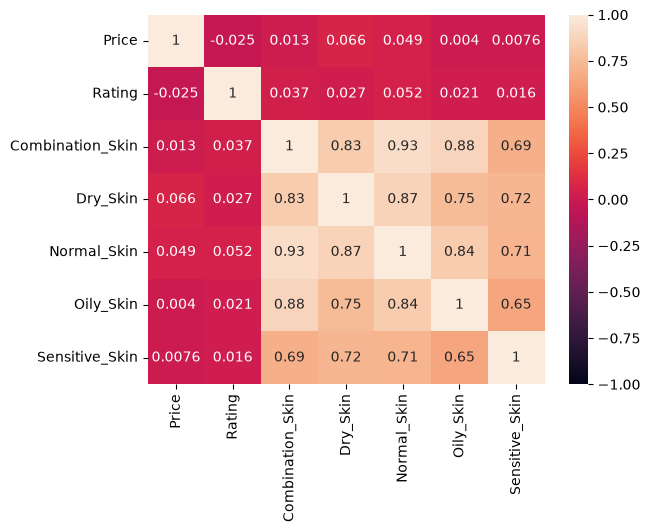

In [22]:
# Create the correlation matrix
corr_matrix_cosmetics = df_cosmetics.corr(numeric_only=True)

sns.heatmap(corr_matrix_cosmetics, vmin=-1, vmax=1, annot=True)

# Model Training

In [23]:
X = df_cosmetics.copy()
X.drop(columns=['Name', 'Ingredients'], inplace=True)

X

,Type,Brand,Price,Rating,Combination_Skin,Dry_Skin,Normal_Skin,Oily_Skin,Sensitive_Skin
0,Moisturizer,LA MER,175,4.1,1,1,1,1,1
1,Moisturizer,SK-II,179,4.1,1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,68,4.4,1,1,1,1,0
3,Moisturizer,LA MER,175,3.8,1,1,1,1,1
4,Moisturizer,IT COSMETICS,38,4.1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...
1467,Sun protect,KORRES,35,3.9,1,1,1,1,1
1468,Sun protect,KATE SOMERVILLE,48,3.6,0,0,0,0,0
1469,Sun protect,VITA LIBERATA,54,3.5,0,0,0,0,0
1470,Sun protect,ST. TROPEZ TANNING ESSENTIALS,20,1.0,0,0,0,0,0


In [24]:
# Splitting numeric and categorical features
numeric_features = ['Rating', 'Price']
categorical_features = ['Brand', 'Type']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough'
)

In [26]:
# Transforming the X data
X_transformed = preprocessor.fit_transform(X)
X_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10368 stored elements and shape (1472, 129)>

In [32]:
# Storage the t-SNE on a DF
results_df = pd.DataFrame()

In [33]:
# Algorithm Training loop, changing the Perplexity param
for perplexity in range(5,51,1):
    tsne = TSNE(n_components=2, perplexity=perplexity, init='random', max_iter=250, random_state=42)
    tsne_results = tsne.fit_transform(X_transformed)

    temp_df = pd.DataFrame(tsne_results, columns=["Component 1", "Component 2"])
    temp_df['Perplexity'] = perplexity

    results_df = pd.concat([results_df, temp_df], axis=0) 

In [36]:
results_df.head(10)

,Component 1,Component 2,Perplexity
0,-1.511144,-0.396497,5
1,-1.605509,-0.475056,5
2,-0.005195,0.211506,5
3,-1.508888,-0.410946,5
4,0.054127,0.765290,5
5,-0.694048,0.241825,5
6,-0.015702,0.225571,5
7,-0.008532,0.209453,5
8,0.158985,0.685044,5
9,-1.639833,-1.420121,5


In [35]:
# Index reset to plot the data
results_df.reset_index(drop=True, inplace=True)

# Visualizing the Data

In [38]:
# Creating a animated scatterplot with variation in perplexity
fig = px.scatter(results_df, x='Component 1', y='Component 2', animation_frame='Perplexity',
                 title="T-SNE visualization with perplexity variation")

fig.show()